In [1]:
"""Proposal-faithful RQ3 artifact generator.

This script reads frozen Phase 3 raw outputs and generates the revised,
no-human-evaluation RQ3 artifacts focused on complementary case-level evidence.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid")


# Update this path in Kaggle before running.
PHASE3_INPUT_ROOT = Path("/kaggle/input/datasets/ashwinwalunj/ashwin-thesis-outputs-phase3/thesis_outputs")
OUTPUT_ROOT = Path("/kaggle/working/thesis_outputs")

RQ = "rq3"
RQ_OUTPUT_ROOT = OUTPUT_ROOT / "results_proposal" / RQ
FIGURES_ROOT = RQ_OUTPUT_ROOT / "figures"
TABLES_ROOT = RQ_OUTPUT_ROOT / "tables"
for folder in [FIGURES_ROOT, TABLES_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

ID_COL = "TransactionID"
TIME_COL = "TransactionDT"


def save_table(df, name):
    df.to_csv(TABLES_ROOT / f"{name}.csv", index=False)


def save_figure(fig, name):
    fig.savefig(FIGURES_ROOT / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES_ROOT / f"{name}.pdf", bbox_inches="tight")
    plt.show()


def truncate_text(value, max_len=48):
    text = str(value)
    if len(text) <= max_len:
        return text
    return text[: max_len - 3] + "..."


PHASE3_ARTIFACTS = PHASE3_INPUT_ROOT / "artifacts" / "phase03_ranking_explainability"

required_files = [
    PHASE3_ARTIFACTS / "case_summary_raw.csv",
    PHASE3_ARTIFACTS / "lgbm_case_feature_explanations_raw.csv",
    PHASE3_ARTIFACTS / "graph_case_evidence_raw.csv",
    PHASE3_ARTIFACTS / "attention_heatmap_cases_raw.csv",
    PHASE3_ARTIFACTS / "reference_case_lgbm_features_raw.csv",
    PHASE3_ARTIFACTS / "reference_case_graph_evidence_raw.csv",
    PHASE3_ARTIFACTS / "reference_case_attention_raw.csv",
]
for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 3 raw file for RQ3: {path}")


case_summary_df = pd.read_csv(PHASE3_ARTIFACTS / "case_summary_raw.csv")
case_feature_df = pd.read_csv(PHASE3_ARTIFACTS / "lgbm_case_feature_explanations_raw.csv")
case_graph_df = pd.read_csv(PHASE3_ARTIFACTS / "graph_case_evidence_raw.csv")
attention_heatmap_df = pd.read_csv(PHASE3_ARTIFACTS / "attention_heatmap_cases_raw.csv")
reference_feature_df = pd.read_csv(PHASE3_ARTIFACTS / "reference_case_lgbm_features_raw.csv")
reference_graph_df = pd.read_csv(PHASE3_ARTIFACTS / "reference_case_graph_evidence_raw.csv")
reference_attention_df = pd.read_csv(PHASE3_ARTIFACTS / "reference_case_attention_raw.csv")


def support_size_for_threshold(weights, threshold=0.80):
    ordered = np.sort(np.asarray(weights, dtype=float))[::-1]
    total = max(float(np.sum(ordered)), 1e-8)
    return int(np.searchsorted(np.cumsum(ordered) / total, threshold) + 1)

In [2]:
# Table 3.1 - Explanation Coverage and Consistency Summary
table_3_1_rows = []

if not case_feature_df.empty:
    shap_case_size = case_feature_df.groupby(ID_COL).size()
    shap_top = case_feature_df.sort_values(["TransactionID", "FeatureRank"]).groupby(ID_COL).head(1).copy()
    shap_top["AbsSHAP"] = shap_top["SHAPValue"].abs()
    shap_totals = case_feature_df.groupby(ID_COL)["SHAPValue"].apply(lambda s: float(np.abs(s).sum()))
    shap_dominance = shap_top.set_index(ID_COL)["AbsSHAP"] / shap_totals.replace(0, np.nan)
    table_3_1_rows.append(
        {
            "Method": "SHAP",
            "Avg Explanation Size": float(shap_case_size.mean()),
            "Top-1 Dominance": float(shap_dominance.mean()),
            "Cross-Case Diversity": float(shap_top["Feature"].astype(str).nunique() / max(len(shap_top), 1)),
            "Signal Type": "Feature attribution",
            "Primary Evidence Pattern": str(shap_top["Feature"].astype(str).mode().iloc[0]),
        }
    )

if not case_graph_df.empty:
    graph_case_size = case_graph_df.groupby(ID_COL).size()
    graph_top = case_graph_df.sort_values([ID_COL, "EdgeWeight"], ascending=[True, False]).groupby(ID_COL).head(1).copy()
    graph_totals = case_graph_df.groupby(ID_COL)["EdgeWeight"].sum()
    graph_dominance = graph_top.set_index(ID_COL)["EdgeWeight"] / graph_totals.replace(0, np.nan)
    graph_top["EntityType"] = graph_top["EntityType"].astype(str)
    table_3_1_rows.append(
        {
            "Method": "Graph Evidence",
            "Avg Explanation Size": float(graph_case_size.mean()),
            "Top-1 Dominance": float(graph_dominance.mean()),
            "Cross-Case Diversity": float(graph_top["EntityType"].nunique() / max(len(graph_top), 1)),
            "Signal Type": "Relational evidence",
            "Primary Evidence Pattern": str(graph_top["EntityType"].mode().iloc[0]),
        }
    )

attention_cols = [col for col in attention_heatmap_df.columns if col.endswith("_attention")]
attention_name_map = {
    "lgbm_score_attention": "LightGBM",
    "xgb_score_attention": "XGBoost",
    "full_TemporalGraphSAGE_score_attention": "TemporalGraphSAGE",
    "full_GraphSAGE_score_attention": "GraphSAGE",
}
if attention_cols:
    attention_matrix = attention_heatmap_df[attention_cols].to_numpy(dtype=float)
    attention_sizes = [support_size_for_threshold(row, threshold=0.80) for row in attention_matrix]
    top_indices = np.argmax(attention_matrix, axis=1)
    top_sources = [attention_name_map.get(attention_cols[idx], attention_cols[idx]) for idx in top_indices]
    table_3_1_rows.append(
        {
            "Method": "Fusion",
            "Avg Explanation Size": float(np.mean(attention_sizes)),
            "Top-1 Dominance": float(np.mean(np.max(attention_matrix, axis=1))),
            "Cross-Case Diversity": float(len(set(top_sources)) / max(len(top_sources), 1)),
            "Signal Type": "Source-level fusion",
            "Primary Evidence Pattern": str(pd.Series(top_sources).mode().iloc[0]),
        }
    )

table_3_1 = pd.DataFrame(table_3_1_rows)
save_table(table_3_1, "table_3_1_explanation_coverage_and_consistency_summary")

In [3]:
# Table 3.2 - Case-Based Analysis
table_3_2_rows = []
for _, row in case_summary_df.iterrows():
    case_label = f"Case {int(row[ID_COL])}"
    decision = row.get("ReviewDecision", "Review")

    top_feature = row.get("TopLightGBMFeature")
    top_shap = row.get("TopLightGBMSHAP")
    if pd.notna(top_feature):
        explanation = f"Top feature: {top_feature}"
        if pd.notna(top_shap):
            explanation += f" (SHAP={float(top_shap):.3f})"
        table_3_2_rows.append(
            {
                "Case": case_label,
                "Method": "SHAP",
                "Explanation": explanation,
                "Decision": decision,
            }
        )

    top_source = row.get("TopAttentionSource")
    top_weight = row.get("TopAttentionWeight")
    if pd.notna(top_source):
        explanation = f"Highest fusion weight assigned to {top_source}"
        if pd.notna(top_weight):
            explanation += f" ({float(top_weight):.3f})"
        table_3_2_rows.append(
            {
                "Case": case_label,
                "Method": "Fusion",
                "Explanation": explanation,
                "Decision": decision,
            }
        )

    entity_type = row.get("TopGraphEntityType")
    entity_key = row.get("TopGraphEntityKey")
    edge_weight = row.get("TopGraphEdgeWeight")
    if pd.notna(entity_type) and pd.notna(entity_key):
        explanation = f"Linked {entity_type}: {truncate_text(entity_key, max_len=36)}"
        if pd.notna(edge_weight):
            explanation += f" (weight={float(edge_weight):.3f})"
        table_3_2_rows.append(
            {
                "Case": case_label,
                "Method": "Graph Evidence",
                "Explanation": explanation,
                "Decision": decision,
            }
        )

table_3_2 = pd.DataFrame(table_3_2_rows)
save_table(table_3_2, "table_3_2_case_based_analysis")

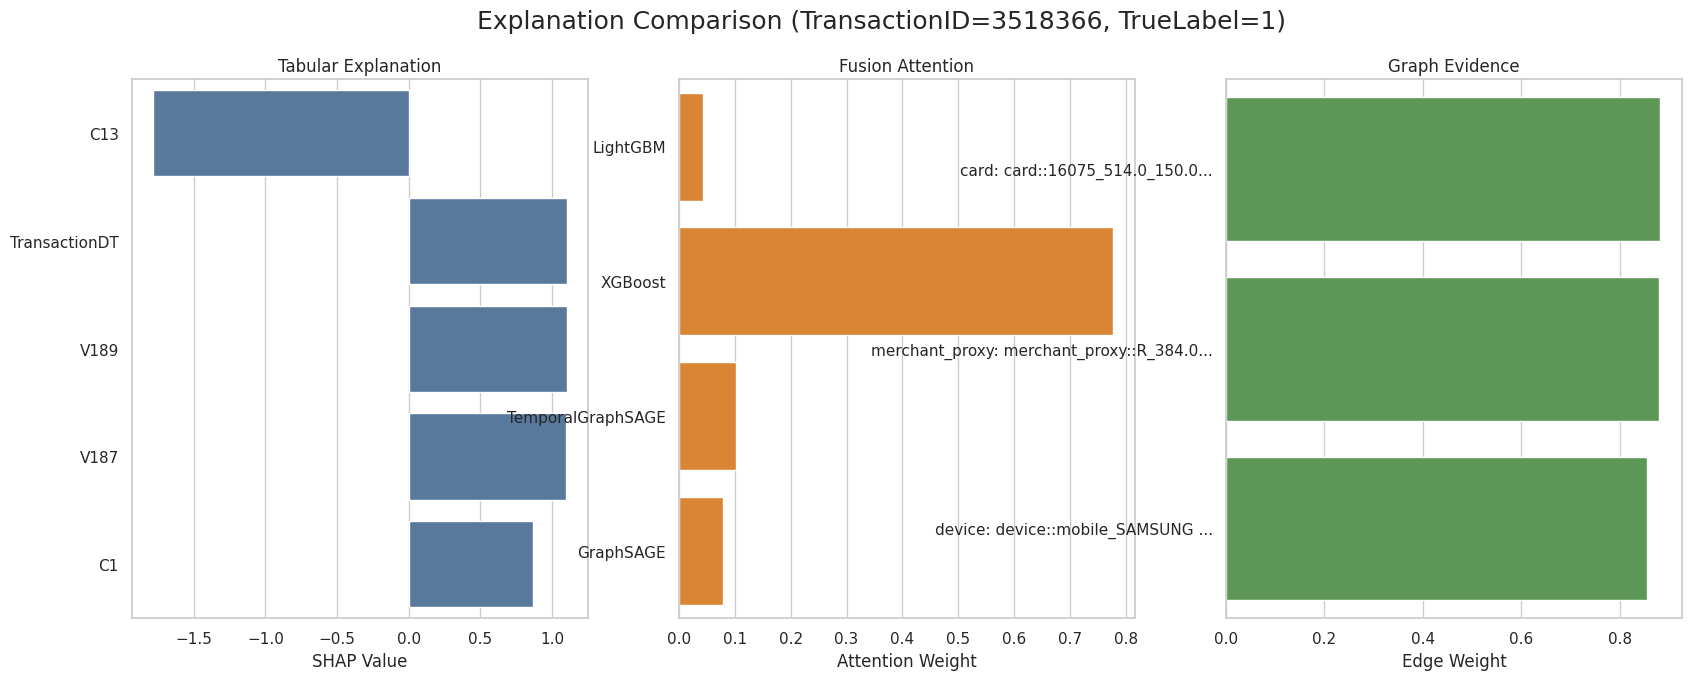

In [4]:
# Figure 3.1 - Explanation Comparison
reference_txn_id = int(reference_attention_df["TransactionID"].iloc[0])
reference_true_label = int(reference_attention_df["TrueLabel"].iloc[0])

feature_plot_df = reference_feature_df.copy()
feature_plot_df["Feature"] = feature_plot_df["Feature"].astype(str)

graph_plot_df = reference_graph_df.copy()
graph_plot_df["EntityLabel"] = (
    graph_plot_df["EntityType"].astype(str)
    + ": "
    + graph_plot_df["EntityKey"].astype(str).map(lambda x: truncate_text(x, max_len=26))
)

attention_plot_df = reference_attention_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

sns.barplot(
    data=feature_plot_df,
    x="SHAPValue",
    y="Feature",
    orient="h",
    color="#4c78a8",
    ax=axes[0],
)
axes[0].set_title("Tabular Explanation")
axes[0].set_xlabel("SHAP Value")
axes[0].set_ylabel("")

sns.barplot(
    data=attention_plot_df,
    x="AttentionWeight",
    y="Source",
    orient="h",
    color="#f58518",
    ax=axes[1],
)
axes[1].set_title("Fusion Attention")
axes[1].set_xlabel("Attention Weight")
axes[1].set_ylabel("")

sns.barplot(
    data=graph_plot_df,
    x="EdgeWeight",
    y="EntityLabel",
    orient="h",
    color="#54a24b",
    ax=axes[2],
)
axes[2].set_title("Graph Evidence")
axes[2].set_xlabel("Edge Weight")
axes[2].set_ylabel("")

fig.suptitle(
    f"Explanation Comparison (TransactionID={reference_txn_id}, TrueLabel={reference_true_label})",
    fontsize=18,
)
save_figure(fig, "figure_3_1_explanation_comparison")

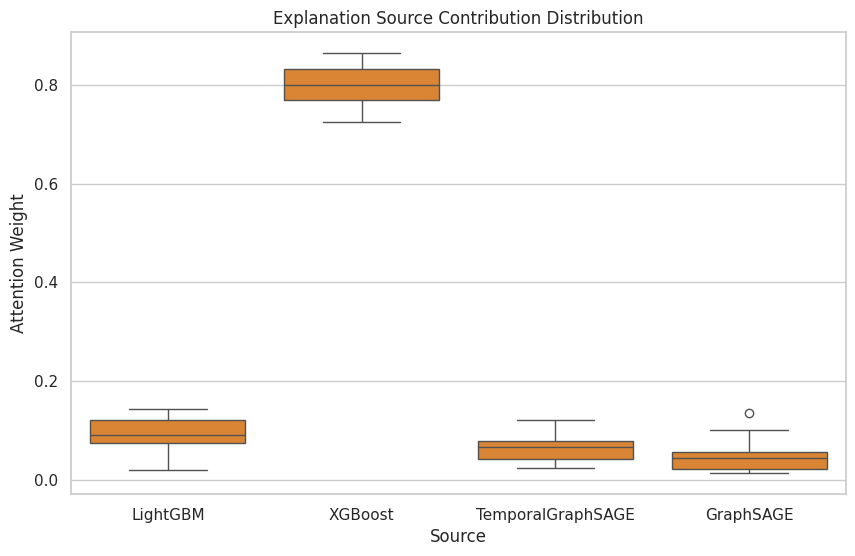

In [5]:
# Figure 3.2 - Explanation Source Contribution Distribution
attention_dist_df = attention_heatmap_df[[ID_COL] + attention_cols].melt(
    id_vars=[ID_COL],
    value_vars=attention_cols,
    var_name="AttentionColumn",
    value_name="AttentionWeight",
)
attention_dist_df["Source"] = attention_dist_df["AttentionColumn"].map(
    lambda col: attention_name_map.get(col, col)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=attention_dist_df,
    x="Source",
    y="AttentionWeight",
    order=["LightGBM", "XGBoost", "TemporalGraphSAGE", "GraphSAGE"],
    color="#f58518",
    ax=ax,
)
ax.set_title("Explanation Source Contribution Distribution")
ax.set_xlabel("Source")
ax.set_ylabel("Attention Weight")
save_figure(fig, "figure_3_2_explanation_source_contribution_distribution")